In [1]:
import pandas as pd
import numpy as np
import os

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, accuracy_score, balanced_accuracy_score,
    f1_score, precision_score, recall_score, matthews_corrcoef,
    cohen_kappa_score, confusion_matrix
)

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [2]:
class HybridDataset(Dataset):
    def __init__(self, X_seq, X_static, y):
        self.X_seq = torch.FloatTensor(X_seq)
        self.X_static = torch.FloatTensor(X_static)
        self.y = torch.LongTensor(y)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X_seq[idx], self.X_static[idx], self.y[idx]


class HybridLSTMModel(nn.Module):
    def __init__(self, input_dim_per_phase, static_dim):
        super().__init__()

        # ===== LSTM branch =====
        self.hidden_dim = 128
        self.num_layers = 1
        self.dropout_p = 0.3
        self.num_classes = 3

        self.lstm = nn.LSTM(
            input_size=input_dim_per_phase,
            hidden_size=self.hidden_dim,
            num_layers=self.num_layers,
            batch_first=True
        )

        self.dropout = nn.Dropout(self.dropout_p)

        # ===== Static branch (MLP) =====
        self.mlp = nn.Sequential(
            nn.Linear(static_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU()
        )

        # ===== Fusion layer =====
        self.fc = nn.Linear(self.hidden_dim + 32, self.num_classes)

    def forward(self, x_seq, x_static):
        # ----- LSTM branch -----
        out, (h_n, c_n) = self.lstm(x_seq)

        # Lấy last hidden state theo đúng yêu cầu
        last_hidden = h_n[-1]

        last_hidden = self.dropout(last_hidden)

        # ----- MLP branch -----
        static_out = self.mlp(x_static)

        # ----- Combine -----
        combined = torch.cat([last_hidden, static_out], dim=1)

        return self.fc(combined)


In [3]:
# Metrics
def gmean_score(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    per_class = []
    for i in range(cm.shape[0]):
        tp = cm[i,i]
        fn = cm[i].sum() - tp
        fp = cm[:,i].sum() - tp
        tn = cm.sum() - tp - fn - fp
        sens = tp / (tp + fn) if (tp + fn) > 0 else 0
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0
        per_class.append(np.sqrt(sens * spec))
    return np.prod(per_class) ** (1/len(per_class)) if per_class else 0

def gmean_per_class(y_true, y_pred, target_class):
    cm = confusion_matrix(y_true, y_pred)
    i = target_class
    tp = cm[i,i]
    fn = cm[i].sum() - tp
    fp = cm[:,i].sum() - tp
    tn = cm.sum() - tp - fn - fp

    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    return np.sqrt(recall * specificity)

def print_results(
    version_name,
    phase,
    y_true,
    y_pred,
    time_build_model=None,
    time_predict=None
):
    target_names = ['Excellent', 'Good', 'Average']

    print(f"\n{'='*30} {version_name} - Phase {phase} {'='*30}")
    print(classification_report(
        y_true,
        y_pred,
        digits=10,
        target_names=target_names
    ))

    # Precision / Recall / F1 theo từng class
    prec_per_class = precision_score(y_true, y_pred, average=None)
    rec_per_class  = recall_score(y_true, y_pred, average=None)
    f1_per_class   = f1_score(y_true, y_pred, average=None)

    # G-Mean per class
    gmean_classes = [
        gmean_per_class(y_true, y_pred, i)
        for i in range(len(target_names))
    ]

    print("G-Mean per class (one-vs-rest):")
    for idx, name in enumerate(target_names):
        print(f"  {name:<10}: {gmean_classes[idx]:.10f}")
        
    print()

    # ===== TẠO DICTIONARY METRICS =====
    metrics = {
        'Version': version_name,
        'Phase': phase,

        'TimeBuildModel': time_build_model,
        'TimePredict': time_predict,

        'Accuracy': accuracy_score(y_true, y_pred),
        'BalancedAcc': balanced_accuracy_score(y_true, y_pred),

        'Precision Macro': precision_score(y_true, y_pred, average='macro'),
        'Precision Weighted': precision_score(y_true, y_pred, average='weighted'),

        'Recall Macro': recall_score(y_true, y_pred, average='macro'),
        'Recall Weighted': recall_score(y_true, y_pred, average='weighted'),

        'F1-Score Macro': f1_score(y_true, y_pred, average='macro'),
        'F1-Score Weighted': f1_score(y_true, y_pred, average='weighted'),

        'GMean': gmean_score(y_true, y_pred),

        'MCC': matthews_corrcoef(y_true, y_pred),
        'Kappa': cohen_kappa_score(y_true, y_pred),
    }

    # ===== THÊM METRIC CHO TỪNG CLASS =====
    for i, name in enumerate(target_names):
        metrics[f'Precision_{name}'] = prec_per_class[i]
        metrics[f'Recall_{name}'] = rec_per_class[i]
        metrics[f'F1-Score_{name}'] = f1_per_class[i]
        metrics[f'G-Mean_{name}'] = gmean_classes[i]

    # In ra console
    for k, v in metrics.items():
        if k not in ['Version', 'Phase'] and v is not None:
            print(f"{k:22} : {v:.10f}")

    return metrics


In [4]:
def evaluate_hybrid_model(
    model,
    loader,
    device,
    dataset_name,
    output_dir="results_LSTM"
):
    os.makedirs(output_dir, exist_ok=True)

    model.eval()

    all_preds = []
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for xb_seq, xb_static, yb in loader:
            xb_seq = xb_seq.to(device)
            xb_static = xb_static.to(device)

            outputs = model(xb_seq, xb_static)

            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(outputs, dim=1)

            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(yb.numpy())

    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)
    y_prob = np.array(all_probs)

    # ===== Confusion Matrix =====
    cm = confusion_matrix(y_true, y_pred)

    cm_path = f"{output_dir}/confusion_matrix_{dataset_name}.csv"
    pd.DataFrame(cm).to_csv(cm_path, index=False)

    # Plot CM
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {dataset_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")


    # ===== Probability matrix =====
    prob_path = f"{output_dir}/probability_matrix_{dataset_name}.csv"

    df_prob = pd.DataFrame(
        y_prob,
        columns=[f"Prob_Class_{i}" for i in range(y_prob.shape[1])]
    )
    df_prob["y_true"] = y_true
    df_prob["y_pred"] = y_pred

    df_prob.to_csv(prob_path, index=False)

    print(f"Saved confusion matrix to: {cm_path}")
    print(f"Saved probability matrix to: {prob_path}")

    return y_true, y_pred


# Hàm chuẩn bị dữ liệu và train

In [5]:
def prepare_and_train_hybrid(train_path, val_path=None):
    print(f"Loading train: {train_path}")
    df_train = pd.read_csv(train_path)

    if val_path:
        df_val = pd.read_csv(val_path)
        df = pd.concat([df_train, df_val], ignore_index=True)
        print(f"Combined train + val: {len(df)} samples")
    else:
        df = df_train
        print(f"Only train: {len(df)} samples")

    df = df.drop(columns=['user_id', 'course_id'], errors='ignore')

    # ===== Tách label =====
    y = df['label_3'].values
    df_features = df.drop('label_3', axis=1)

    # Lấy tất cả feature time-series của cả 4 phase
    phase_cols = [
        col for col in df_features.columns
        if any(f"_p{p}_" in col for p in ['1', '2', '3', '4'])
    ]
    
    phases_data = []
    
    for p in ['1', '2', '3', '4']:
        cols_p = [c for c in phase_cols if f"_p{p}_" in c]
        print(f"Phase {p}: {len(cols_p)} features")
        phases_data.append(df_features[cols_p].values)
    
    X_seq = np.stack(phases_data, axis=1)
    
    print(f"Time-series shape: {X_seq.shape}")


    # ====== Tách feature static ======
    static_cols = [c for c in df_features.columns if c not in phase_cols]
    X_static = df_features[static_cols].values

    print(f"Static feature shape: {X_static.shape}")

    # ====== Chuẩn hóa ======
    scaler_seq = StandardScaler()
    N, T, F = X_seq.shape

    X_seq = scaler_seq.fit_transform(X_seq.reshape(-1, F)).reshape(N, T, F)

    scaler_static = StandardScaler()
    X_static = scaler_static.fit_transform(X_static)

    # ===== Encode label =====
    le = LabelEncoder()
    y_enc = le.fit_transform(y)

    print(f"Classes: {le.classes_}")

    # ===== Dataset =====
    dataset = HybridDataset(X_seq, X_static, y_enc)
    loader = DataLoader(dataset, batch_size=256, shuffle=True)

    # ===== Model =====
    model = HybridLSTMModel(
        input_dim_per_phase=F,
        static_dim=X_static.shape[1]
    ).to(device)

    # ===== Training Config =====
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # ===== Train =====
    model.train()
    best_loss = float('inf')
    patience = 10
    wait = 0

    for epoch in range(50):
        epoch_loss = 0

        for xb_seq, xb_static, yb in loader:
            xb_seq = xb_seq.to(device)
            xb_static = xb_static.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            out = model(xb_seq, xb_static)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        epoch_loss /= len(loader)
        print(f"Epoch {epoch+1}: loss = {epoch_loss:.4f}")

        if epoch_loss < best_loss - 1e-4:
            best_loss = epoch_loss
            best_state = model.state_dict()
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

    model.load_state_dict(best_state)
    model.eval()

    print("Training done")

    return model, scaler_seq, scaler_static, le, phase_cols, static_cols


In [6]:
def run_and_report_hybrid(
    model,
    loader,
    device,
    dataset_name,
    version_name="HybridModel",
    phase="All"
):
    y_true, y_pred = evaluate_hybrid_model(
        model, loader, device, dataset_name
    )

    metrics = print_results(
        version_name=version_name,
        phase=phase,
        y_true=y_true,
        y_pred=y_pred
    )

    return metrics


# Chạy từng version

In [7]:
import time

def run_experiment(
    base_path,
    train_file,
    val_file,
    test_prefix,
    version_name
):
    print(f"\n{'#'*5}")
    print(f"Version: {version_name}")
    print(f"{'#'*5}")

    train_path = f"{base_path}/{train_file}"
    val_path   = f"{base_path}/{val_file}"

    test_files = [
        f"{base_path}/{test_prefix}_1.csv",
        f"{base_path}/{test_prefix}_2.csv",
        f"{base_path}/{test_prefix}_3.csv",
        f"{base_path}/{test_prefix}_4.csv",
    ]

    # ===== Train hybrid model =====
    start_train = time.perf_counter()

    model, scaler_seq, scaler_static, le, phase_cols, static_cols = \
        prepare_and_train_hybrid(train_path, val_path)

    time_build_model = time.perf_counter() - start_train

    results = []
    model.eval()

    with torch.no_grad():
        for phase, test_path in enumerate(test_files, 1):
            print(f"\n--- Test Phase {phase}: {test_path} ---")

            df_test = pd.read_csv(test_path)
            df_test = df_test.drop(columns=['user_id', 'course_id'], errors='ignore')

            y_test = df_test['label_3'].values
            df_features = df_test.drop('label_3', axis=1)

            # ===== TÁCH TIME SERIES =====
            phases_data = []
    
            for p in ['1', '2', '3', '4']:
                cols_p = [c for c in phase_cols if f"_p{p}_" in c]
                phases_data.append(df_features[cols_p].values)
    
            X_seq = np.stack(phases_data, axis=1)

            # ===== Split static features =====
            X_static = df_features[static_cols].values

            # ===== Scaling =====
            N, T, F = X_seq.shape
            X_seq_scaled = scaler_seq.transform(
                X_seq.reshape(-1, F)
            ).reshape(N, T, F)

            X_static_scaled = scaler_static.transform(X_static)

            # ===== Convert to tensor =====
            X_seq_tensor = torch.FloatTensor(X_seq_scaled).to(device)
            X_static_tensor = torch.FloatTensor(X_static_scaled).to(device)

            # ===== Predict =====
            start_pred = time.perf_counter()

            outputs = model(X_seq_tensor, X_static_tensor)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()

            time_predict = time.perf_counter() - start_pred

            y_test_enc = le.transform(y_test)

            # ===== In metrics =====
            res = print_results(
                version_name=version_name,
                phase=phase,
                y_true=y_test_enc,
                y_pred=preds,
                time_build_model=time_build_model,
                time_predict=time_predict
            )

            # ===== Xuất confusion + probability =====
            run_and_report_hybrid(
                model=model,
                loader=DataLoader(
                    HybridDataset(X_seq_scaled, X_static_scaled, y_test_enc),
                    batch_size=256
                ),
                device=device,
                dataset_name=f"{version_name}_phase{phase}"
            )

            results.append(res)

    # ===== Tạo dataframe tổng hợp =====
    df = pd.DataFrame(results).round(10)

    # Đổi tên cột cho đúng (giữ nguyên logic cũ của bạn)
    df = df.rename(columns={
        "PrecMacro": "Precision Macro",
        "PrecWeighted": "Precision Weighted",
        "RecMacro": "Recall Macro",
        "RecWeighted": "Recall Weighted",
        "F1Macro": "F1-Score Macro",
        "F1Weighted": "F1-Score Weighted",
    })

    ordered_cols = [
        "Version",
        "Phase",
        "TimeBuildModel",
        "TimePredict",
        "Accuracy",
        "BalancedAcc",
        "Precision Macro",
        "Precision Weighted",
        "Recall Macro",
        "Recall Weighted",
        "F1-Score Macro",
        "F1-Score Weighted",
        "GMean",
        "MCC",
        "Kappa",

        "Precision_Excellent",
        "Recall_Excellent",
        "F1-Score_Excellent",
        "G-Mean_Excellent",

        "Precision_Good",
        "Recall_Good",
        "F1-Score_Good",
        "G-Mean_Good",

        "Precision_Average",
        "Recall_Average",
        "F1-Score_Average",
        "G-Mean_Average",
    ]

    ordered_cols = [c for c in ordered_cols if c in df.columns]

    df = df[ordered_cols]

    return df


## V1 (Meadian)

In [8]:
base_path = "/kaggle/input/lo-dataset/Median/Median"


#####
Version: V1 (Median)
#####
Loading train: /kaggle/input/lo-dataset/Median/Median/train_median.csv
Combined train + val: 2092071 samples
Phase 1: 39 features
Phase 2: 39 features
Phase 3: 39 features
Phase 4: 39 features
Time-series shape: (2092071, 4, 39)
Static feature shape: (2092071, 23)
Classes: [0 1 2]
Epoch 1: loss = 0.0090
Epoch 2: loss = 0.0055
Epoch 3: loss = 0.0050
Epoch 4: loss = 0.0047
Epoch 5: loss = 0.0044
Epoch 6: loss = 0.0042
Epoch 7: loss = 0.0041
Epoch 8: loss = 0.0039
Epoch 9: loss = 0.0037
Epoch 10: loss = 0.0036
Epoch 11: loss = 0.0035
Epoch 12: loss = 0.0034
Epoch 13: loss = 0.0033
Epoch 14: loss = 0.0032
Epoch 15: loss = 0.0032
Epoch 16: loss = 0.0031
Epoch 17: loss = 0.0030
Epoch 18: loss = 0.0030
Epoch 19: loss = 0.0029
Epoch 20: loss = 0.0028
Epoch 21: loss = 0.0028
Epoch 22: loss = 0.0027
Epoch 23: loss = 0.0027
Epoch 24: loss = 0.0027
Epoch 25: loss = 0.0026
Epoch 26: loss = 0.0026
Epoch 27: loss = 0.0026
Epoch 28: loss = 0.0025
Epoch 29: loss = 0.00

,Version,Phase,TimeBuildModel,TimePredict,Accuracy,BalancedAcc,Precision Macro,Precision Weighted,Recall Macro,Recall Weighted,F1-Score Macro,F1-Score Weighted,GMean,MCC,Kappa,Precision_Excellent,Recall_Excellent,F1-Score_Excellent,G-Mean_Excellent,Precision_Good,Recall_Good,F1-Score_Good,G-Mean_Good,Precision_Average,Recall_Average,F1-Score_Average,G-Mean_Average
0,V1 (Median),1,1687.080632,0.098677,0.975126,0.513676,0.685429,0.995957,0.513676,0.975126,0.372989,0.984448,0.398039,0.178026,0.117053,1.000000,0.013453,0.026549,0.115987,0.057883,0.550413,0.104750,0.733175,0.998403,0.977161,0.987668,0.741585
1,V1 (Median),2,1687.080632,0.081517,0.984775,0.559087,0.589311,0.996029,0.559087,0.984775,0.437416,0.989676,0.558736,0.259479,0.201075,0.666667,0.080717,0.144000,0.284103,0.102585,0.609917,0.175631,0.775516,0.998680,0.986625,0.992616,0.791687
2,V1 (Median),3,1687.080632,0.080057,0.974537,0.636385,0.654252,0.996129,0.636385,0.974537,0.529098,0.984511,0.703477,0.209348,0.135007,0.903614,0.336323,0.490196,0.579924,0.060479,0.596694,0.109827,0.763060,0.998662,0.976138,0.987271,0.786720
3,V1 (Median),4,1687.080632,0.080274,0.998555,0.844573,0.885264,0.998476,0.844573,0.998555,0.863510,0.998504,0.872734,0.786387,0.785139,0.868182,0.856502,0.862302,0.925416,0.788462,0.677686,0.728889,0.823022,0.999150,0.999529,0.999340,0.872765


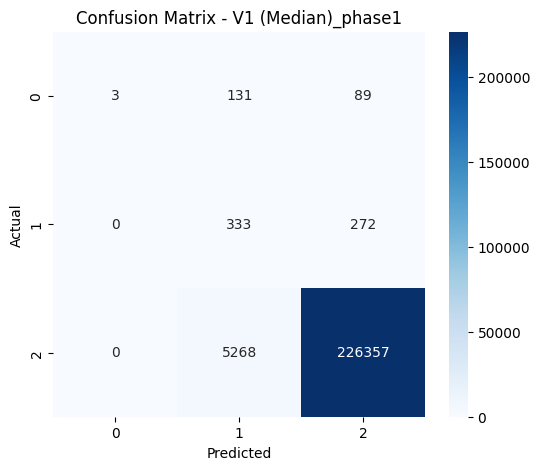

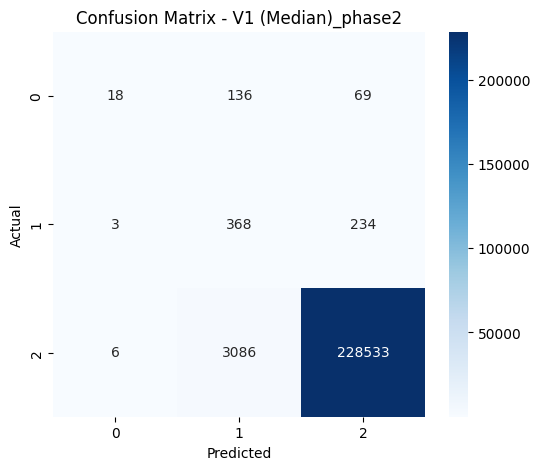

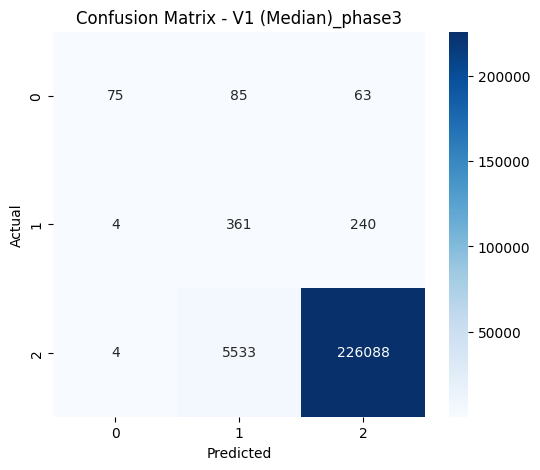

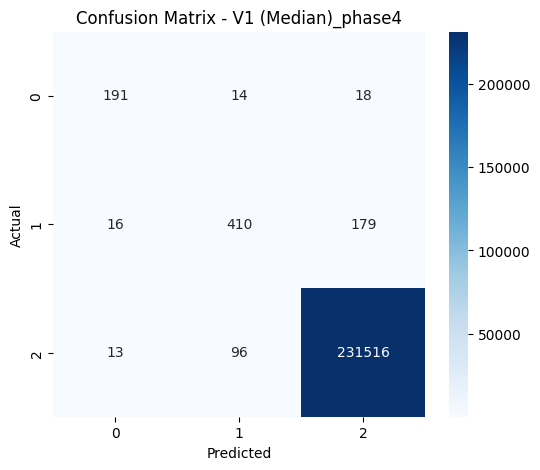

In [9]:
df_v1 = run_experiment(
    base_path=base_path,
    train_file="train_median.csv",
    val_file="val.csv",
    test_prefix="test",
    version_name="V1 (Median)"
)
df_v1

In [10]:
df_v1.to_csv("results_v1.csv", index=False)

## V2 (Median_CDSMOTE)


#####
Version: V2 (Median CDSMOTE)
#####
Loading train: /kaggle/input/lo-dataset/Median/Median/train_median_cdsmote.csv
Combined train + val: 5791443 samples
Phase 1: 39 features
Phase 2: 39 features
Phase 3: 39 features
Phase 4: 39 features
Time-series shape: (5791443, 4, 39)
Static feature shape: (5791443, 23)
Classes: [0 1 2]
Epoch 1: loss = 0.0510
Epoch 2: loss = 0.0248
Epoch 3: loss = 0.0207
Epoch 4: loss = 0.0187
Epoch 5: loss = 0.0173
Epoch 6: loss = 0.0164
Epoch 7: loss = 0.0157
Epoch 8: loss = 0.0150
Epoch 9: loss = 0.0146
Epoch 10: loss = 0.0141
Epoch 11: loss = 0.0138
Epoch 12: loss = 0.0135
Epoch 13: loss = 0.0132
Epoch 14: loss = 0.0130
Epoch 15: loss = 0.0129
Epoch 16: loss = 0.0127
Epoch 17: loss = 0.0125
Epoch 18: loss = 0.0124
Epoch 19: loss = 0.0123
Epoch 20: loss = 0.0121
Epoch 21: loss = 0.0119
Epoch 22: loss = 0.0118
Epoch 23: loss = 0.0118
Epoch 24: loss = 0.0117
Epoch 25: loss = 0.0116
Epoch 26: loss = 0.0114
Epoch 27: loss = 0.0114
Epoch 28: loss = 0.0113
Epoch

,Version,Phase,TimeBuildModel,TimePredict,Accuracy,BalancedAcc,Precision Macro,Precision Weighted,Recall Macro,Recall Weighted,F1-Score Macro,F1-Score Weighted,GMean,MCC,Kappa,Precision_Excellent,Recall_Excellent,F1-Score_Excellent,G-Mean_Excellent,Precision_Good,Recall_Good,F1-Score_Good,G-Mean_Good,Precision_Average,Recall_Average,F1-Score_Average,G-Mean_Average
0,V2 (Median CDSMOTE),1,4504.184755,0.079728,0.996563,0.374949,0.891275,0.995808,0.374949,0.996563,0.407540,0.994967,0.182739,0.187527,0.072908,0.962963,0.116592,0.208000,0.341455,0.714286,0.008264,0.016340,0.090909,0.996575,0.999991,0.998280,0.196588
1,V2 (Median CDSMOTE),2,4504.184755,0.079886,0.996718,0.472915,0.761916,0.995412,0.472915,0.996718,0.532359,0.995536,0.372789,0.310913,0.231732,0.811881,0.367713,0.506173,0.606369,0.476923,0.051240,0.092537,0.226345,0.996943,0.999793,0.998366,0.377469
2,V2 (Median CDSMOTE),3,4504.184755,0.079957,0.997105,0.597587,0.787947,0.996203,0.597587,0.997105,0.646844,0.996306,0.547903,0.462414,0.416449,0.807692,0.659193,0.725926,0.811846,0.558621,0.133884,0.216000,0.365852,0.997527,0.999685,0.998605,0.553775
3,V2 (Median CDSMOTE),4,4504.184755,0.079738,0.996098,0.890855,0.636657,0.997668,0.890855,0.996098,0.725882,0.996690,0.923270,0.636245,0.608959,0.451765,0.860987,0.592593,0.927428,0.458605,0.814876,0.586905,0.901571,0.999602,0.996702,0.998150,0.941253


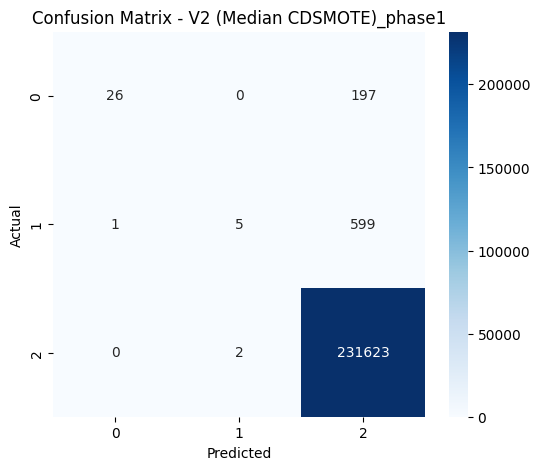

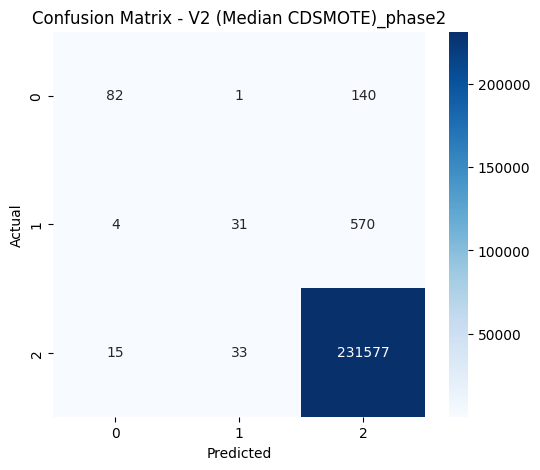

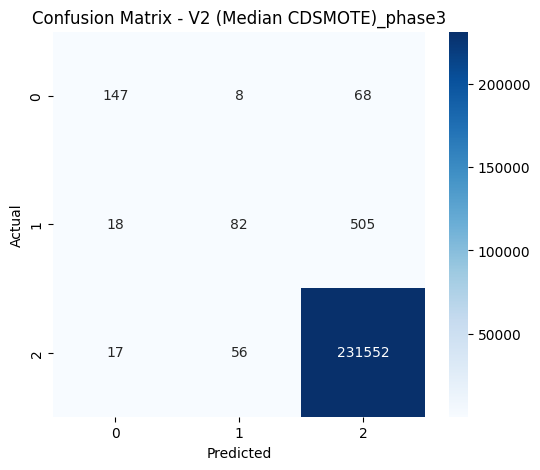

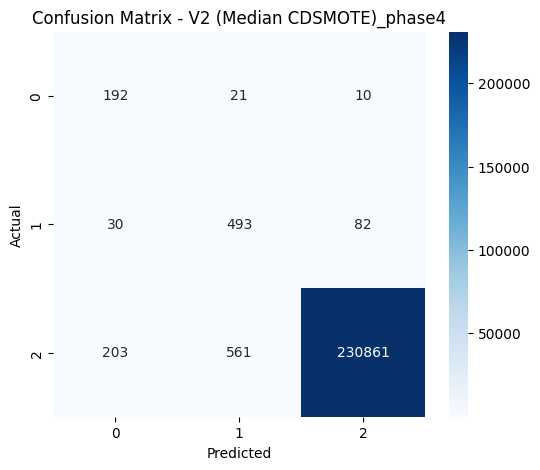

In [11]:
df_v2 = run_experiment(
    base_path=base_path,
    train_file="train_median_cdsmote.csv",
    val_file="val.csv",
    test_prefix="test",
    version_name="V2 (Median CDSMOTE)"
)

df_v2

In [12]:
df_v2.to_csv("results_v2.csv", index=False)

## V3 (Median SASMOTE)


#####
Version: V3 (Median SASMOTE)
#####
Loading train: /kaggle/input/lo-dataset/Median/Median/train_median_sasmote.csv
Combined train + val: 5791443 samples
Phase 1: 39 features
Phase 2: 39 features
Phase 3: 39 features
Phase 4: 39 features
Time-series shape: (5791443, 4, 39)
Static feature shape: (5791443, 23)
Classes: [0 1 2]
Epoch 1: loss = 0.0508
Epoch 2: loss = 0.0250
Epoch 3: loss = 0.0209
Epoch 4: loss = 0.0189
Epoch 5: loss = 0.0176
Epoch 6: loss = 0.0166
Epoch 7: loss = 0.0160
Epoch 8: loss = 0.0153
Epoch 9: loss = 0.0147
Epoch 10: loss = 0.0143
Epoch 11: loss = 0.0140
Epoch 12: loss = 0.0137
Epoch 13: loss = 0.0135
Epoch 14: loss = 0.0132
Epoch 15: loss = 0.0129
Epoch 16: loss = 0.0127
Epoch 17: loss = 0.0125
Epoch 18: loss = 0.0124
Epoch 19: loss = 0.0123
Epoch 20: loss = 0.0121
Epoch 21: loss = 0.0120
Epoch 22: loss = 0.0118
Epoch 23: loss = 0.0118
Epoch 24: loss = 0.0116
Epoch 25: loss = 0.0115
Epoch 26: loss = 0.0114
Epoch 27: loss = 0.0114
Epoch 28: loss = 0.0113
Epoch

,Version,Phase,TimeBuildModel,TimePredict,Accuracy,BalancedAcc,Precision Macro,Precision Weighted,Recall Macro,Recall Weighted,F1-Score Macro,F1-Score Weighted,GMean,MCC,Kappa,Precision_Excellent,Recall_Excellent,F1-Score_Excellent,G-Mean_Excellent,Precision_Good,Recall_Good,F1-Score_Good,G-Mean_Good,Precision_Average,Recall_Average,F1-Score_Average,G-Mean_Average
0,V3 (Median SASMOTE),1,4147.351845,0.079716,0.996016,0.483038,0.568681,0.994848,0.483038,0.996016,0.498301,0.995216,0.430720,0.256228,0.239098,0.334746,0.354260,0.344227,0.594996,0.374194,0.095868,0.152632,0.309560,0.997104,0.998985,0.998044,0.433837
1,V3 (Median SASMOTE),2,4147.351845,0.079691,0.996133,0.526861,0.599359,0.995151,0.526861,0.996133,0.519080,0.995314,0.454687,0.292292,0.275550,0.368421,0.502242,0.425047,0.708397,0.432432,0.079339,0.134078,0.281633,0.997225,0.999003,0.998113,0.471169
2,V3 (Median SASMOTE),3,4147.351845,0.079689,0.995212,0.677867,0.575653,0.995913,0.677867,0.995212,0.571227,0.995345,0.661753,0.382409,0.381005,0.268882,0.798206,0.402260,0.892492,0.460064,0.238017,0.313725,0.487692,0.998013,0.997379,0.997696,0.665793
3,V3 (Median SASMOTE),4,4147.351845,0.079674,0.996180,0.900618,0.633950,0.997749,0.900618,0.996180,0.725200,0.996765,0.930590,0.646214,0.618144,0.413276,0.865471,0.559420,0.929758,0.488932,0.839669,0.618005,0.915285,0.999641,0.996715,0.998175,0.946996


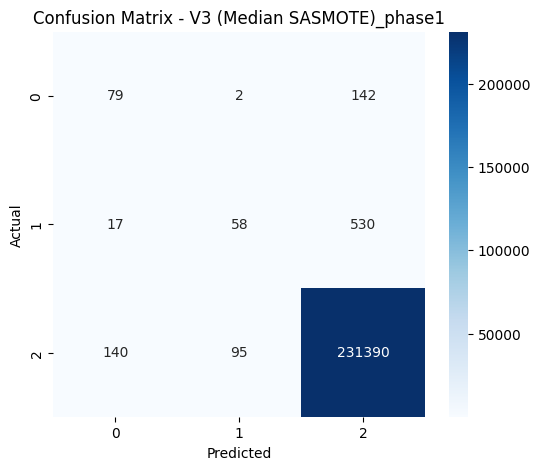

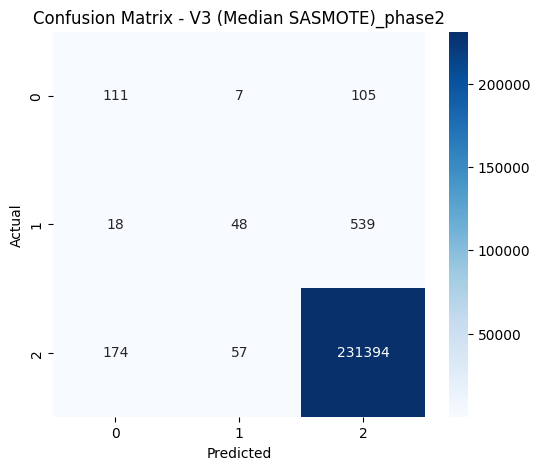

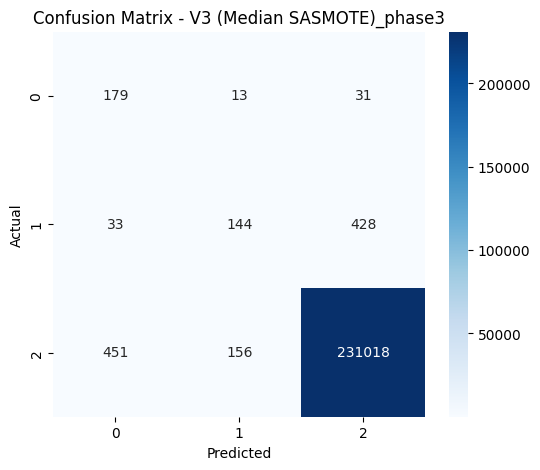

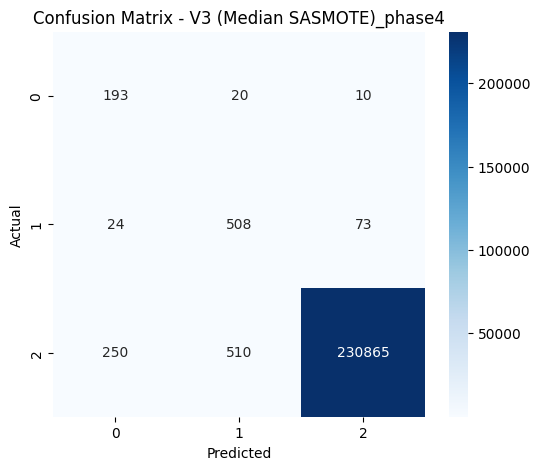

In [13]:
df_v3 = run_experiment(
    base_path=base_path,
    train_file="train_median_sasmote.csv",
    val_file="val.csv",
    test_prefix="test",
    version_name="V3 (Median SASMOTE)"
)

df_v3

In [14]:
df_v3.to_csv("results_v3.csv", index=False)

## V4 (Median RadiusSMOTE)


#####
Version: V4 (Median RadiusSMOTE)
#####
Loading train: /kaggle/input/lo-dataset/Median/Median/train_median_radiussmote.csv
Combined train + val: 5791443 samples
Phase 1: 39 features
Phase 2: 39 features
Phase 3: 39 features
Phase 4: 39 features
Time-series shape: (5791443, 4, 39)
Static feature shape: (5791443, 23)
Classes: [0 1 2]
Epoch 1: loss = 0.0427
Epoch 2: loss = 0.0181
Epoch 3: loss = 0.0148
Epoch 4: loss = 0.0133
Epoch 5: loss = 0.0123
Epoch 6: loss = 0.0115
Epoch 7: loss = 0.0110
Epoch 8: loss = 0.0106
Epoch 9: loss = 0.0102
Epoch 10: loss = 0.0100
Epoch 11: loss = 0.0098
Epoch 12: loss = 0.0095
Epoch 13: loss = 0.0094
Epoch 14: loss = 0.0092
Epoch 15: loss = 0.0091
Epoch 16: loss = 0.0089
Epoch 17: loss = 0.0088
Epoch 18: loss = 0.0087
Epoch 19: loss = 0.0085
Epoch 20: loss = 0.0085
Epoch 21: loss = 0.0084
Epoch 22: loss = 0.0082
Epoch 23: loss = 0.0082
Epoch 24: loss = 0.0081
Epoch 25: loss = 0.0081
Epoch 26: loss = 0.0080
Epoch 27: loss = 0.0079
Epoch 28: loss = 0.00

,Version,Phase,TimeBuildModel,TimePredict,Accuracy,BalancedAcc,Precision Macro,Precision Weighted,Recall Macro,Recall Weighted,F1-Score Macro,F1-Score Weighted,GMean,MCC,Kappa,Precision_Excellent,Recall_Excellent,F1-Score_Excellent,G-Mean_Excellent,Precision_Good,Recall_Good,F1-Score_Good,G-Mean_Good,Precision_Average,Recall_Average,F1-Score_Average,G-Mean_Average
0,V4 (Median RadiusSMOTE),1,3980.875714,0.079620,0.996158,0.413830,0.562039,0.994735,0.413830,0.996158,0.450908,0.995198,0.353244,0.220145,0.190729,0.252427,0.116592,0.159509,0.341399,0.436782,0.125620,0.195122,0.354354,0.996908,0.999279,0.998092,0.364355
1,V4 (Median RadiusSMOTE),2,3980.875714,0.079638,0.996429,0.464359,0.643931,0.995363,0.464359,0.996429,0.515256,0.995637,0.443406,0.308743,0.277137,0.400000,0.215247,0.279883,0.463875,0.534653,0.178512,0.267658,0.422422,0.997140,0.999318,0.998228,0.444896
2,V4 (Median RadiusSMOTE),3,3980.875714,0.079580,0.994696,0.676248,0.564850,0.995617,0.676248,0.994696,0.609238,0.995115,0.688392,0.378640,0.373636,0.454286,0.713004,0.554974,0.844049,0.242158,0.319008,0.275321,0.564072,0.998106,0.996732,0.997419,0.685183
3,V4 (Median RadiusSMOTE),4,3980.875714,0.079538,0.997113,0.819182,0.686604,0.997607,0.819182,0.997113,0.740331,0.997317,0.863063,0.651145,0.645718,0.504249,0.798206,0.618056,0.893087,0.556328,0.661157,0.604230,0.812556,0.999235,0.998182,0.998708,0.885891


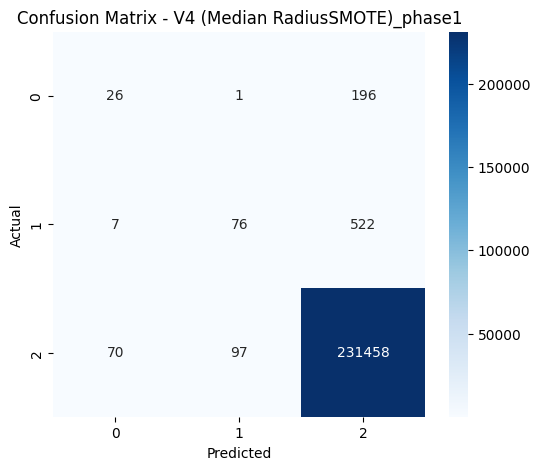

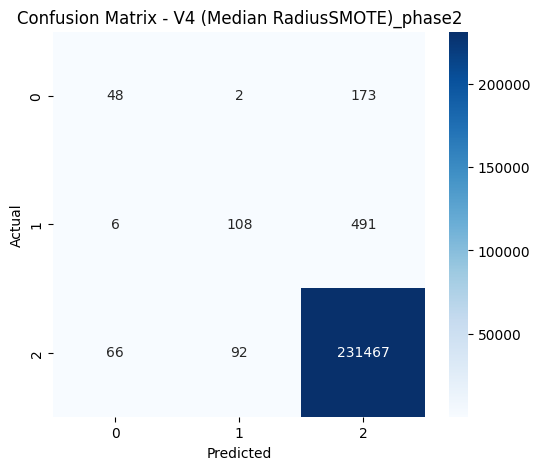

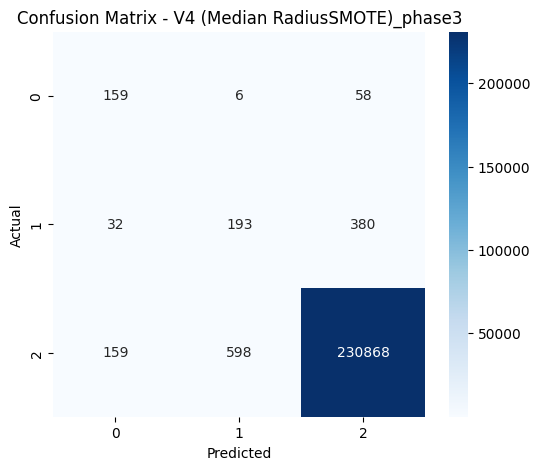

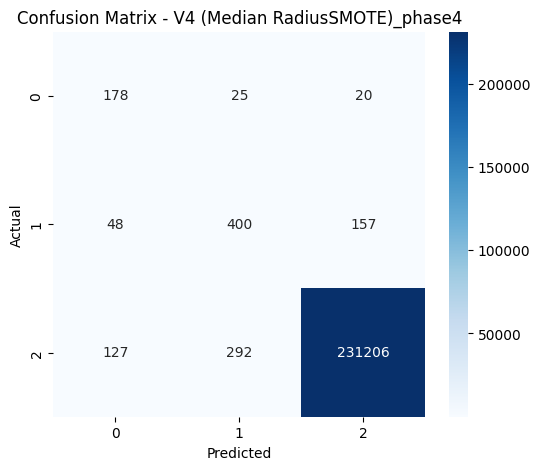

In [15]:
df_v4 = run_experiment(
    base_path=base_path,
    train_file="train_median_radiussmote.csv",
    val_file="val.csv",
    test_prefix="test",
    version_name="V4 (Median RadiusSMOTE)"
)

df_v4

In [16]:
df_v4.to_csv("results_v4.csv", index=False)

## V5 (Mean)

In [17]:
base_path = "/kaggle/input/lo-dataset/Mean/Mean"


#####
Version: V5 (Mean)
#####
Loading train: /kaggle/input/lo-dataset/Mean/Mean/train_mean.csv
Combined train + val: 2092071 samples
Phase 1: 39 features
Phase 2: 39 features
Phase 3: 39 features
Phase 4: 39 features
Time-series shape: (2092071, 4, 39)
Static feature shape: (2092071, 23)
Classes: [0 1 2]
Epoch 1: loss = 0.0086
Epoch 2: loss = 0.0055
Epoch 3: loss = 0.0049
Epoch 4: loss = 0.0047
Epoch 5: loss = 0.0044
Epoch 6: loss = 0.0042
Epoch 7: loss = 0.0040
Epoch 8: loss = 0.0038
Epoch 9: loss = 0.0037
Epoch 10: loss = 0.0035
Epoch 11: loss = 0.0035
Epoch 12: loss = 0.0034
Epoch 13: loss = 0.0032
Epoch 14: loss = 0.0032
Epoch 15: loss = 0.0031
Epoch 16: loss = 0.0030
Epoch 17: loss = 0.0030
Epoch 18: loss = 0.0030
Epoch 19: loss = 0.0029
Epoch 20: loss = 0.0029
Epoch 21: loss = 0.0029
Epoch 22: loss = 0.0028
Epoch 23: loss = 0.0028
Epoch 24: loss = 0.0027
Epoch 25: loss = 0.0027
Epoch 26: loss = 0.0027
Epoch 27: loss = 0.0026
Epoch 28: loss = 0.0026
Epoch 29: loss = 0.0026
Epoch

,Version,Phase,TimeBuildModel,TimePredict,Accuracy,BalancedAcc,Precision Macro,Precision Weighted,Recall Macro,Recall Weighted,F1-Score Macro,F1-Score Weighted,GMean,MCC,Kappa,Precision_Excellent,Recall_Excellent,F1-Score_Excellent,G-Mean_Excellent,Precision_Good,Recall_Good,F1-Score_Good,G-Mean_Good,Precision_Average,Recall_Average,F1-Score_Average,G-Mean_Average
0,V5 (Mean),1,1394.105628,0.079741,0.996632,0.391160,0.964695,0.996562,0.391160,0.996632,0.432672,0.995106,0.231399,0.233101,0.106941,0.897436,0.156951,0.267176,0.396167,1.000000,0.016529,0.032520,0.128565,0.996648,1.000000,0.998321,0.243267
1,V5 (Mean),2,1394.105628,0.079631,0.997096,0.521664,0.892644,0.996840,0.521664,0.997096,0.591691,0.996133,0.483220,0.435061,0.350279,0.753846,0.439462,0.555241,0.662874,0.926829,0.125620,0.221252,0.354424,0.997257,0.999909,0.998581,0.480266
2,V5 (Mean),3,1394.105628,0.079658,0.997621,0.644255,0.921632,0.997490,0.644255,0.997621,0.706618,0.996965,0.625678,0.578513,0.523382,0.823834,0.713004,0.764423,0.844334,0.943262,0.219835,0.356568,0.468857,0.997799,0.999927,0.998861,0.618726
3,V5 (Mean),4,1394.105628,0.079607,0.998619,0.841679,0.900158,0.998548,0.841679,0.998619,0.869305,0.998574,0.873786,0.795788,0.794466,0.915842,0.829596,0.870588,0.910788,0.785448,0.695868,0.737949,0.833980,0.999184,0.999573,0.999378,0.878299


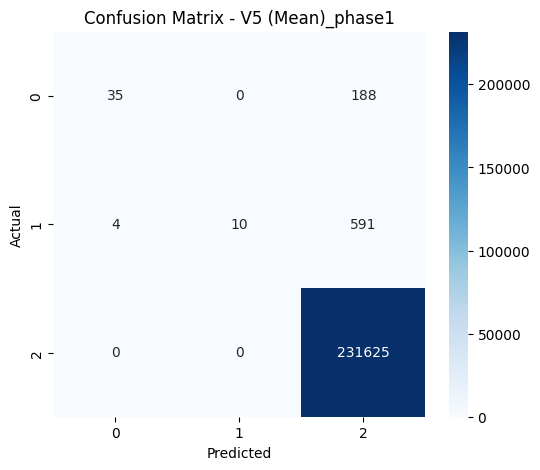

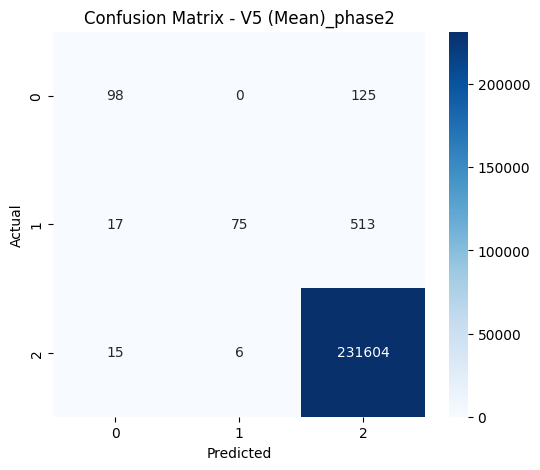

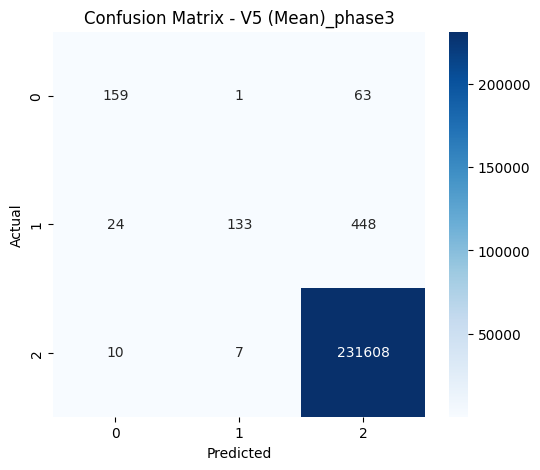

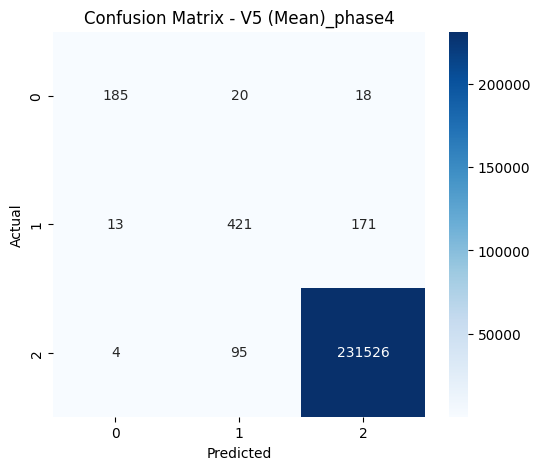

In [18]:
df_v5 = run_experiment(
    base_path=base_path,
    train_file="train_mean.csv",
    val_file="val.csv",
    test_prefix="test",
    version_name="V5 (Mean)"
)

df_v5

In [19]:
df_v5.to_csv("results_v5.csv", index=False)

## V6 (Mean CDSMOTE)


#####
Version: V6 (Mean CDS)
#####
Loading train: /kaggle/input/lo-dataset/Mean/Mean/train_mean_cdsmote.csv
Combined train + val: 5791443 samples
Phase 1: 39 features
Phase 2: 39 features
Phase 3: 39 features
Phase 4: 39 features
Time-series shape: (5791443, 4, 39)
Static feature shape: (5791443, 23)
Classes: [0 1 2]
Epoch 1: loss = 0.0519
Epoch 2: loss = 0.0274
Epoch 3: loss = 0.0233
Epoch 4: loss = 0.0210
Epoch 5: loss = 0.0193
Epoch 6: loss = 0.0182
Epoch 7: loss = 0.0173
Epoch 8: loss = 0.0168
Epoch 9: loss = 0.0162
Epoch 10: loss = 0.0158
Epoch 11: loss = 0.0154
Epoch 12: loss = 0.0151
Epoch 13: loss = 0.0149
Epoch 14: loss = 0.0147
Epoch 15: loss = 0.0144
Epoch 16: loss = 0.0142
Epoch 17: loss = 0.0140
Epoch 18: loss = 0.0138
Epoch 19: loss = 0.0137
Epoch 20: loss = 0.0135
Epoch 21: loss = 0.0134
Epoch 22: loss = 0.0132
Epoch 23: loss = 0.0131
Epoch 24: loss = 0.0131
Epoch 25: loss = 0.0130
Epoch 26: loss = 0.0128
Epoch 27: loss = 0.0128
Epoch 28: loss = 0.0126
Epoch 29: loss = 

,Version,Phase,TimeBuildModel,TimePredict,Accuracy,BalancedAcc,Precision Macro,Precision Weighted,Recall Macro,Recall Weighted,F1-Score Macro,F1-Score Weighted,GMean,MCC,Kappa,Precision_Excellent,Recall_Excellent,F1-Score_Excellent,G-Mean_Excellent,Precision_Good,Recall_Good,F1-Score_Good,G-Mean_Good,Precision_Average,Recall_Average,F1-Score_Average,G-Mean_Average
0,V6 (Mean CDS),1,4307.94559,0.079580,0.989056,0.659502,0.454277,0.995257,0.659502,0.989056,0.446019,0.991785,0.605407,0.226787,0.198454,0.092404,0.856502,0.166812,0.921728,0.272414,0.130579,0.176536,0.361192,0.998014,0.991426,0.994709,0.666503
1,V6 (Mean CDS),2,4307.94559,0.079837,0.987499,0.668503,0.543779,0.995901,0.668503,0.987499,0.436573,0.990938,0.581408,0.204405,0.172699,0.078856,0.914798,0.145196,0.951531,0.554545,0.100826,0.170629,0.317498,0.997937,0.989885,0.993894,0.650547
2,V6 (Mean CDS),3,4307.94559,0.079786,0.990527,0.723429,0.588185,0.996605,0.723429,0.990527,0.533674,0.993101,0.722935,0.303856,0.270278,0.100731,0.865471,0.180458,0.926849,0.665493,0.312397,0.425197,0.558810,0.998332,0.992419,0.995367,0.729497
3,V6 (Mean CDS),4,4307.94559,0.079991,0.996098,0.883711,0.628872,0.997618,0.883711,0.996098,0.716425,0.996677,0.916248,0.629828,0.604395,0.408511,0.860987,0.554113,0.927338,0.478564,0.793388,0.597015,0.889718,0.999541,0.996758,0.998147,0.932284


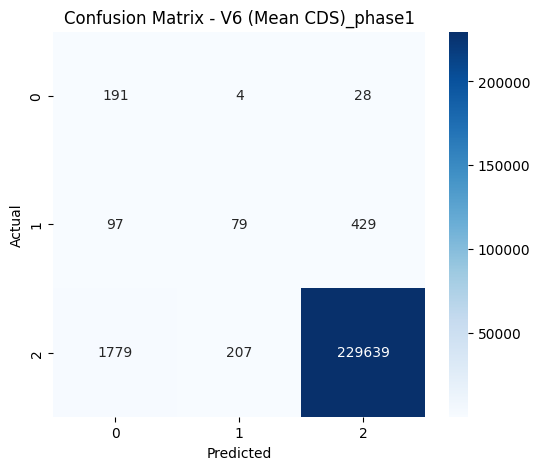

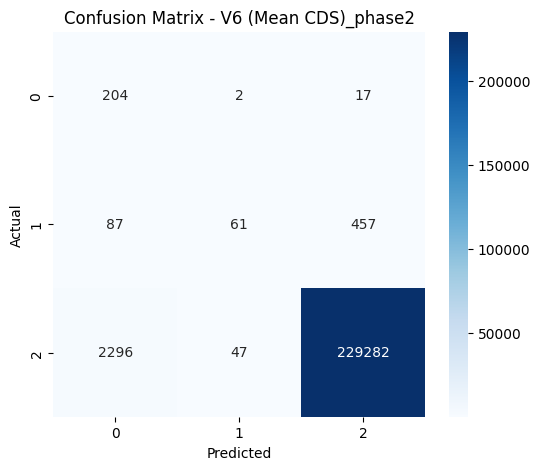

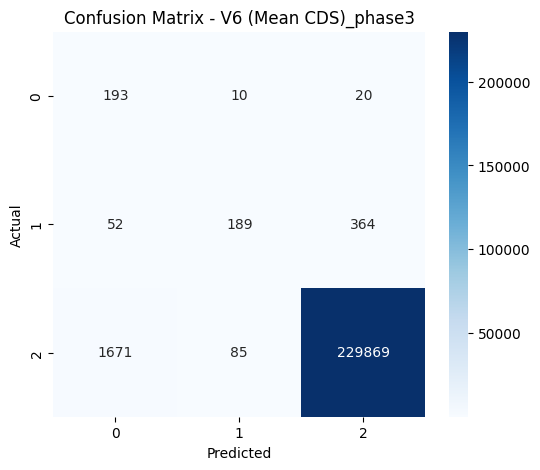

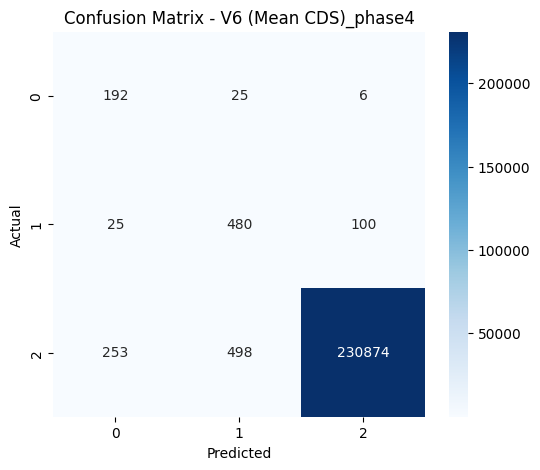

In [20]:
df_v6 = run_experiment(
    base_path=base_path,
    train_file="train_mean_cdsmote.csv",
    val_file="val.csv",
    test_prefix="test",
    version_name="V6 (Mean CDS)"
)
df_v6

In [21]:
df_v6.to_csv("results_v6.csv", index=False)

## V7 (Mean SASMOTE)


#####
Version: V7 (Mean SAS)
#####
Loading train: /kaggle/input/lo-dataset/Mean/Mean/train_mean_sasmote.csv
Combined train + val: 5791443 samples
Phase 1: 39 features
Phase 2: 39 features
Phase 3: 39 features
Phase 4: 39 features
Time-series shape: (5791443, 4, 39)
Static feature shape: (5791443, 23)
Classes: [0 1 2]
Epoch 1: loss = 0.0529
Epoch 2: loss = 0.0279
Epoch 3: loss = 0.0233
Epoch 4: loss = 0.0211
Epoch 5: loss = 0.0197
Epoch 6: loss = 0.0185
Epoch 7: loss = 0.0178
Epoch 8: loss = 0.0172
Epoch 9: loss = 0.0166
Epoch 10: loss = 0.0161
Epoch 11: loss = 0.0158
Epoch 12: loss = 0.0155
Epoch 13: loss = 0.0152
Epoch 14: loss = 0.0148
Epoch 15: loss = 0.0147
Epoch 16: loss = 0.0145
Epoch 17: loss = 0.0142
Epoch 18: loss = 0.0140
Epoch 19: loss = 0.0138
Epoch 20: loss = 0.0137
Epoch 21: loss = 0.0135
Epoch 22: loss = 0.0134
Epoch 23: loss = 0.0133
Epoch 24: loss = 0.0132
Epoch 25: loss = 0.0130
Epoch 26: loss = 0.0129
Epoch 27: loss = 0.0129
Epoch 28: loss = 0.0128
Epoch 29: loss = 

,Version,Phase,TimeBuildModel,TimePredict,Accuracy,BalancedAcc,Precision Macro,Precision Weighted,Recall Macro,Recall Weighted,F1-Score Macro,F1-Score Weighted,GMean,MCC,Kappa,Precision_Excellent,Recall_Excellent,F1-Score_Excellent,G-Mean_Excellent,Precision_Good,Recall_Good,F1-Score_Good,G-Mean_Good,Precision_Average,Recall_Average,F1-Score_Average,G-Mean_Average
0,V7 (Mean SAS),1,4202.66941,0.079761,0.989748,0.616321,0.363798,0.994210,0.616321,0.989748,0.388004,0.991679,0.000000,0.183429,0.165846,0.093719,0.856502,0.168952,0.921786,0.000000,0.000000,0.000000,0.000000,0.997674,0.992462,0.995061,0.591607
1,V7 (Mean SAS),2,4202.66941,0.079788,0.994898,0.616228,0.719025,0.996629,0.616228,0.994898,0.466968,0.994474,0.420747,0.276775,0.276517,0.230961,0.829596,0.361328,0.909613,0.928571,0.021488,0.042003,0.146586,0.997544,0.997600,0.997572,0.558615
2,V7 (Mean SAS),3,4202.66941,0.079801,0.993581,0.730830,0.647220,0.996970,0.730830,0.993581,0.560679,0.994708,0.716784,0.367260,0.351854,0.161927,0.919283,0.275353,0.956599,0.781395,0.277686,0.409756,0.526906,0.998337,0.995523,0.996928,0.730637
3,V7 (Mean SAS),4,4202.66941,0.079796,0.995504,0.906999,0.612035,0.997576,0.906999,0.995504,0.707833,0.996283,0.933341,0.614250,0.578555,0.408998,0.896861,0.561798,0.946438,0.427474,0.828099,0.563872,0.908682,0.999632,0.996037,0.997831,0.945403


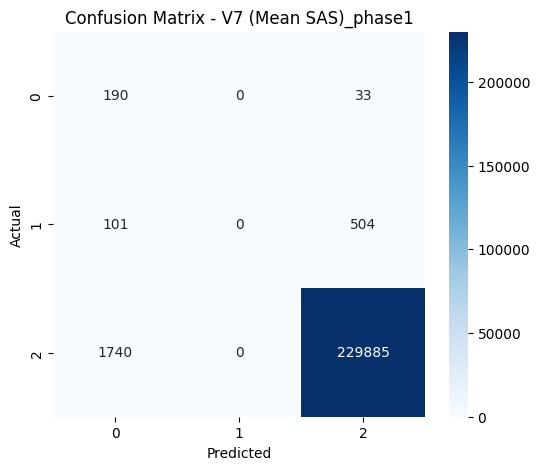

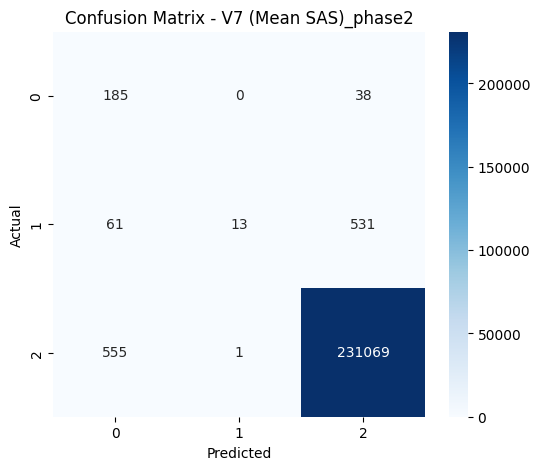

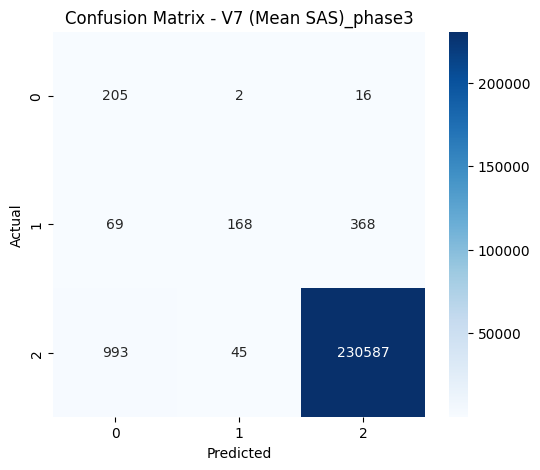

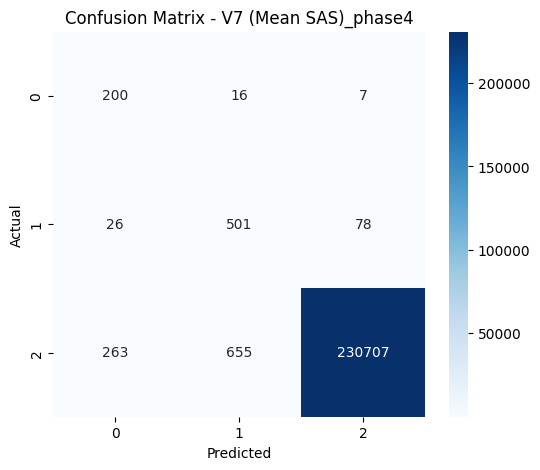

In [22]:
df_v7 = run_experiment(
    base_path=base_path,
    train_file="train_mean_sasmote.csv",
    val_file="val.csv",
    test_prefix="test",
    version_name="V7 (Mean SAS)"
)
df_v7

In [23]:
df_v7.to_csv("results_v7.csv", index=False)

## V8 (Mean RadiusSMOTE)


#####
Version: V8 (Mean Radius)
#####
Loading train: /kaggle/input/lo-dataset/Mean/Mean/train_mean_radiussmote.csv
Combined train + val: 5791443 samples
Phase 1: 39 features
Phase 2: 39 features
Phase 3: 39 features
Phase 4: 39 features
Time-series shape: (5791443, 4, 39)
Static feature shape: (5791443, 23)
Classes: [0 1 2]
Epoch 1: loss = 0.0488
Epoch 2: loss = 0.0231
Epoch 3: loss = 0.0182
Epoch 4: loss = 0.0158
Epoch 5: loss = 0.0146
Epoch 6: loss = 0.0136
Epoch 7: loss = 0.0129
Epoch 8: loss = 0.0123
Epoch 9: loss = 0.0118
Epoch 10: loss = 0.0115
Epoch 11: loss = 0.0112
Epoch 12: loss = 0.0110
Epoch 13: loss = 0.0108
Epoch 14: loss = 0.0106
Epoch 15: loss = 0.0103
Epoch 16: loss = 0.0102
Epoch 17: loss = 0.0101
Epoch 18: loss = 0.0099
Epoch 19: loss = 0.0098
Epoch 20: loss = 0.0096
Epoch 21: loss = 0.0096
Epoch 22: loss = 0.0095
Epoch 23: loss = 0.0094
Epoch 24: loss = 0.0093
Epoch 25: loss = 0.0092
Epoch 26: loss = 0.0092
Epoch 27: loss = 0.0091
Epoch 28: loss = 0.0091
Epoch 29: 

,Version,Phase,TimeBuildModel,TimePredict,Accuracy,BalancedAcc,Precision Macro,Precision Weighted,Recall Macro,Recall Weighted,F1-Score Macro,F1-Score Weighted,GMean,MCC,Kappa,Precision_Excellent,Recall_Excellent,F1-Score_Excellent,G-Mean_Excellent,Precision_Good,Recall_Good,F1-Score_Good,G-Mean_Good,Precision_Average,Recall_Average,F1-Score_Average,G-Mean_Average
0,V8 (Mean Radius),1,4212.982883,0.080061,0.995375,0.469884,0.524311,0.994731,0.469884,0.995375,0.492224,0.995033,0.462280,0.256983,0.254215,0.289655,0.188341,0.228261,0.433886,0.286017,0.223140,0.250696,0.472034,0.997261,0.998169,0.997715,0.482354
1,V8 (Mean Radius),2,4212.982883,0.079982,0.992682,0.584004,0.518835,0.995097,0.584004,0.992682,0.540994,0.993807,0.618778,0.279219,0.267167,0.398305,0.421525,0.409586,0.649051,0.160348,0.335537,0.216996,0.577926,0.997852,0.994949,0.996398,0.631618
2,V8 (Mean Radius),3,4212.982883,0.079750,0.996825,0.692621,0.671714,0.996813,0.692621,0.996825,0.679695,0.996810,0.743221,0.550671,0.550658,0.494545,0.609865,0.546185,0.780705,0.522059,0.469421,0.494343,0.684759,0.998536,0.998575,0.998556,0.767944
3,V8 (Mean Radius),4,4212.982883,0.079578,0.996761,0.830592,0.672819,0.997632,0.830592,0.996761,0.736675,0.997112,0.880221,0.645372,0.632852,0.536050,0.766816,0.630996,0.875401,0.482986,0.727273,0.580475,0.851936,0.999420,0.997686,0.998552,0.914453


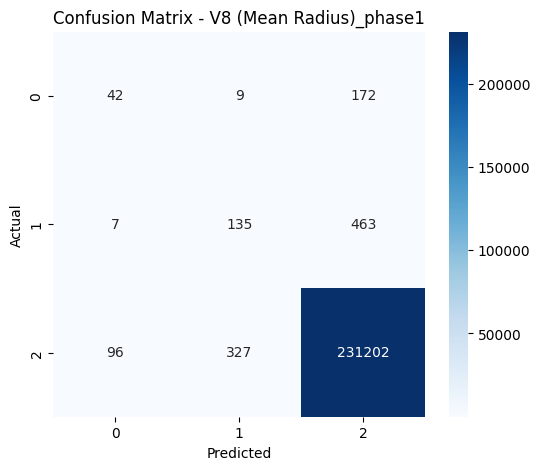

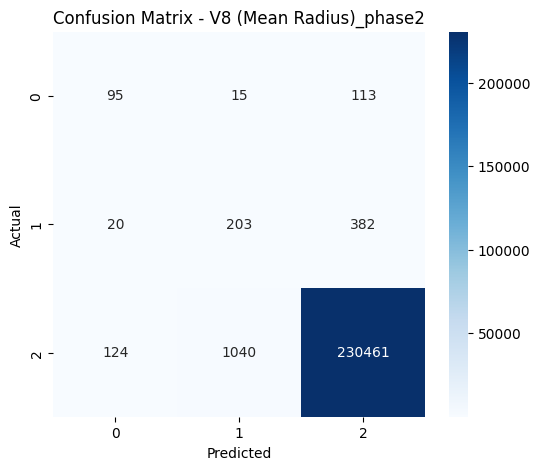

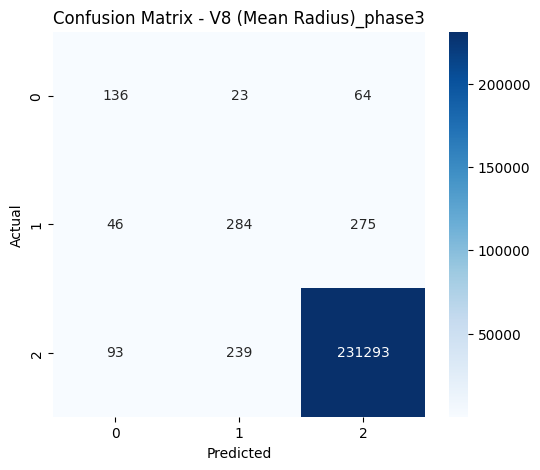

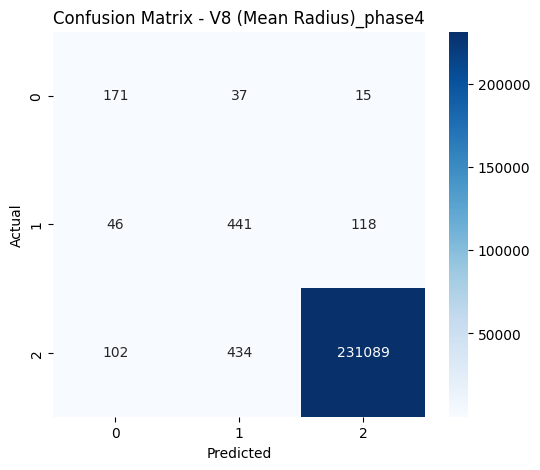

In [24]:
df_v8 = run_experiment(
    base_path=base_path,
    train_file="train_mean_radiussmote.csv",
    val_file="val.csv",
    test_prefix="test",
    version_name="V8 (Mean Radius)"
)
df_v8

In [25]:
df_v8.to_csv("results_v8.csv", index=False)

## V9 (MissForest)

In [26]:
base_path = "/kaggle/input/lo-dataset/Extra_trees/Extra_trees"


#####
Version: V9 (Extra)
#####
Loading train: /kaggle/input/lo-dataset/Extra_trees/Extra_trees/train_extra.csv
Combined train + val: 2092071 samples
Phase 1: 39 features
Phase 2: 39 features
Phase 3: 39 features
Phase 4: 39 features
Time-series shape: (2092071, 4, 39)
Static feature shape: (2092071, 23)
Classes: [0 1 2]
Epoch 1: loss = 0.0094
Epoch 2: loss = 0.0055
Epoch 3: loss = 0.0048
Epoch 4: loss = 0.0044
Epoch 5: loss = 0.0040
Epoch 6: loss = 0.0037
Epoch 7: loss = 0.0035
Epoch 8: loss = 0.0033
Epoch 9: loss = 0.0031
Epoch 10: loss = 0.0030
Epoch 11: loss = 0.0028
Epoch 12: loss = 0.0027
Epoch 13: loss = 0.0026
Epoch 14: loss = 0.0026
Epoch 15: loss = 0.0025
Epoch 16: loss = 0.0024
Epoch 17: loss = 0.0023
Epoch 18: loss = 0.0022
Epoch 19: loss = 0.0022
Epoch 20: loss = 0.0022
Epoch 21: loss = 0.0021
Epoch 22: loss = 0.0021
Epoch 23: loss = 0.0021
Epoch 24: loss = 0.0020
Epoch 25: loss = 0.0020
Epoch 26: loss = 0.0019
Epoch 27: loss = 0.0019
Epoch 28: loss = 0.0019
Epoch 29: los

,Version,Phase,TimeBuildModel,TimePredict,Accuracy,BalancedAcc,Precision Macro,Precision Weighted,Recall Macro,Recall Weighted,F1-Score Macro,F1-Score Weighted,GMean,MCC,Kappa,Precision_Excellent,Recall_Excellent,F1-Score_Excellent,G-Mean_Excellent,Precision_Good,Recall_Good,F1-Score_Good,G-Mean_Good,Precision_Average,Recall_Average,F1-Score_Average,G-Mean_Average
0,V9 (Extra),1,1465.620857,0.080114,0.994167,0.401708,0.435568,0.993691,0.401708,0.994167,0.414251,0.993916,0.319718,0.105936,0.105508,0.226562,0.130045,0.165242,0.360540,0.083333,0.077686,0.080411,0.278411,0.996807,0.997392,0.997100,0.325581
1,V9 (Extra),2,1465.620857,0.079702,0.991723,0.600252,0.513434,0.995802,0.600252,0.991723,0.512148,0.993620,0.647513,0.285975,0.265389,0.073485,0.434978,0.125729,0.657789,0.468750,0.371901,0.414747,0.609501,0.998066,0.993878,0.995968,0.677147
2,V9 (Extra),3,1465.620857,0.079670,0.987098,0.760532,0.437671,0.995875,0.760532,0.987098,0.499438,0.990972,0.807943,0.325789,0.261442,0.157582,0.713004,0.258117,0.842849,0.156557,0.580165,0.246575,0.758573,0.998874,0.988425,0.993622,0.824886
3,V9 (Extra),4,1465.620857,0.079745,0.998658,0.864629,0.879797,0.998619,0.864629,0.998658,0.871841,0.998636,0.893588,0.806536,0.806274,0.853982,0.865471,0.859688,0.930241,0.786096,0.728926,0.756432,0.853550,0.999314,0.999491,0.999402,0.898643


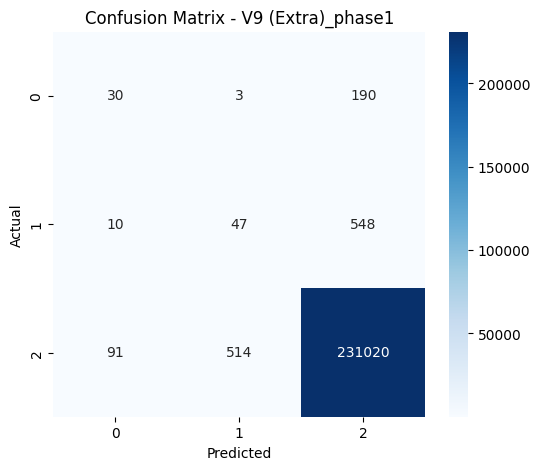

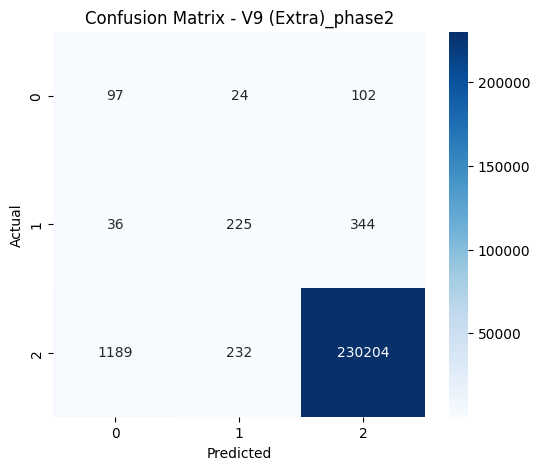

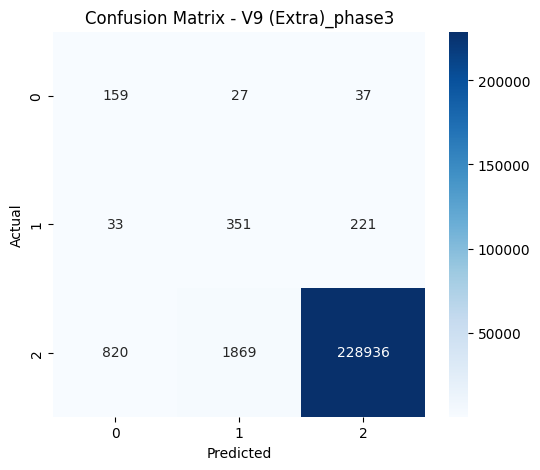

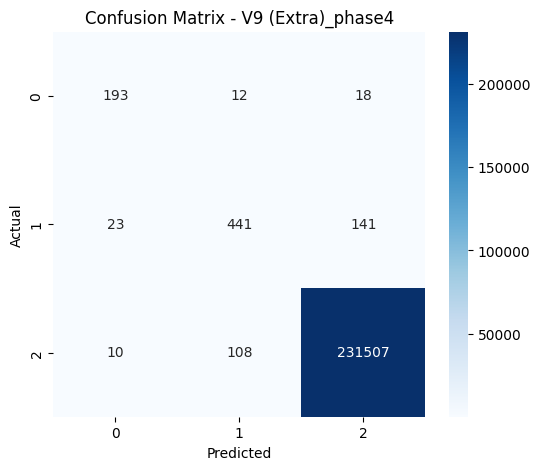

In [27]:
df_v9 = run_experiment(
    base_path=base_path,
    train_file="train_extra.csv",
    val_file="val.csv",
    test_prefix="test",
    version_name="V9 (Extra)"
)
df_v9

In [28]:
df_v9.to_csv("results_v9.csv", index=False)

## V10 (MissForest CDSMOTE)


#####
Version: V10 (Extra CDS)
#####
Loading train: /kaggle/input/lo-dataset/Extra_trees/Extra_trees/train_extra_cdsmote.csv
Combined train + val: 5791443 samples
Phase 1: 39 features
Phase 2: 39 features
Phase 3: 39 features
Phase 4: 39 features
Time-series shape: (5791443, 4, 39)
Static feature shape: (5791443, 23)
Classes: [0 1 2]
Epoch 1: loss = 0.0444
Epoch 2: loss = 0.0188
Epoch 3: loss = 0.0149
Epoch 4: loss = 0.0130
Epoch 5: loss = 0.0117
Epoch 6: loss = 0.0109
Epoch 7: loss = 0.0103
Epoch 8: loss = 0.0099
Epoch 9: loss = 0.0095
Epoch 10: loss = 0.0092
Epoch 11: loss = 0.0089
Epoch 12: loss = 0.0087
Epoch 13: loss = 0.0085
Epoch 14: loss = 0.0083
Epoch 15: loss = 0.0082
Epoch 16: loss = 0.0081
Epoch 17: loss = 0.0080
Epoch 18: loss = 0.0079
Epoch 19: loss = 0.0078
Epoch 20: loss = 0.0077
Epoch 21: loss = 0.0076
Epoch 22: loss = 0.0076
Epoch 23: loss = 0.0075
Epoch 24: loss = 0.0075
Epoch 25: loss = 0.0074
Epoch 26: loss = 0.0073
Epoch 27: loss = 0.0073
Epoch 28: loss = 0.0072


,Version,Phase,TimeBuildModel,TimePredict,Accuracy,BalancedAcc,Precision Macro,Precision Weighted,Recall Macro,Recall Weighted,F1-Score Macro,F1-Score Weighted,GMean,MCC,Kappa,Precision_Excellent,Recall_Excellent,F1-Score_Excellent,G-Mean_Excellent,Precision_Good,Recall_Good,F1-Score_Good,G-Mean_Good,Precision_Average,Recall_Average,F1-Score_Average,G-Mean_Average
0,V10 (Extra CDS),1,4234.894503,0.079932,0.996438,0.333333,0.332146,0.992889,0.333333,0.996438,0.332739,0.994660,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.996438,1.000000,0.998216,0.000000
1,V10 (Extra CDS),2,4234.894503,0.079851,0.996438,0.333333,0.332153,0.992910,0.333333,0.996438,0.332742,0.994671,0.000000,0.038671,0.005966,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.996459,1.000000,0.998227,0.077709
2,V10 (Extra CDS),3,4234.894503,0.079956,0.996756,0.522541,0.703270,0.996000,0.522541,0.996756,0.573550,0.996082,0.525309,0.398288,0.366934,0.476471,0.363229,0.412214,0.602569,0.635897,0.204959,0.310000,0.452654,0.997441,0.999434,0.998437,0.531459
3,V10 (Extra CDS),4,4234.894503,0.079774,0.996885,0.867392,0.668602,0.997803,0.867392,0.996885,0.743952,0.997239,0.905104,0.667941,0.653066,0.456140,0.816143,0.585209,0.902984,0.550173,0.788430,0.648098,0.887189,0.999494,0.997604,0.998548,0.925547


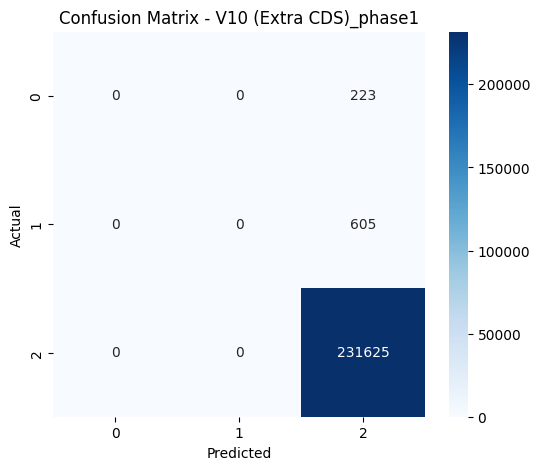

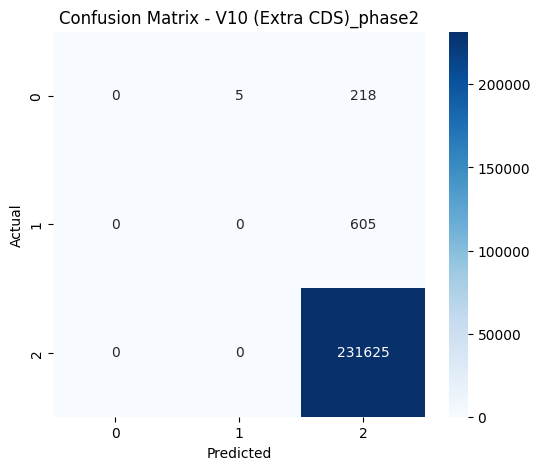

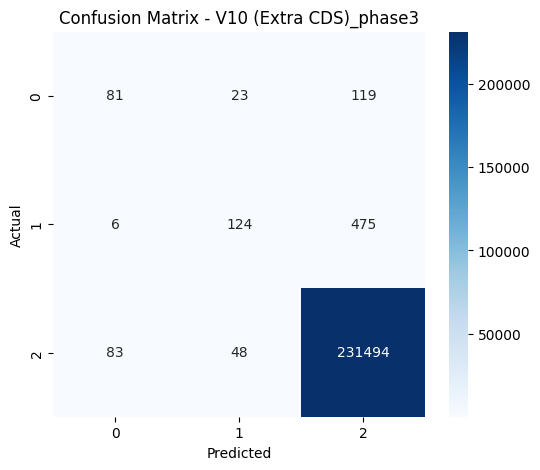

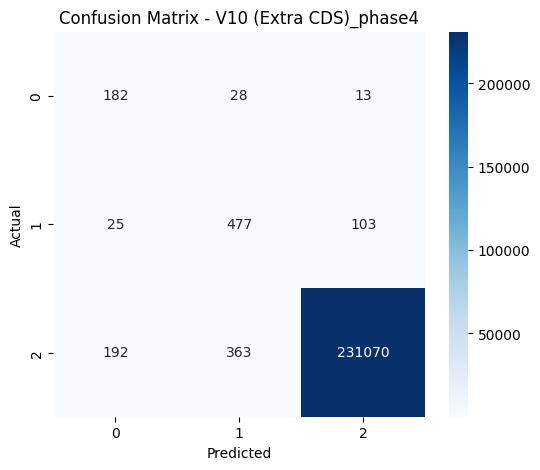

In [29]:
df_v10 = run_experiment(
    base_path=base_path,
    train_file="train_extra_cdsmote.csv",
    val_file="val.csv",
    test_prefix="test",
    version_name="V10 (Extra CDS)"
)
df_v10

In [30]:
df_v10.to_csv("results_v10.csv", index=False)

## V11 (MissForest SASMOTE)


#####
Version: V11 (Extra SAS)
#####
Loading train: /kaggle/input/lo-dataset/Extra_trees/Extra_trees/train_extra_sasmote.csv
Combined train + val: 5791443 samples
Phase 1: 39 features
Phase 2: 39 features
Phase 3: 39 features
Phase 4: 39 features
Time-series shape: (5791443, 4, 39)
Static feature shape: (5791443, 23)
Classes: [0 1 2]
Epoch 1: loss = 0.0440
Epoch 2: loss = 0.0182
Epoch 3: loss = 0.0146
Epoch 4: loss = 0.0127
Epoch 5: loss = 0.0116
Epoch 6: loss = 0.0107
Epoch 7: loss = 0.0102
Epoch 8: loss = 0.0097
Epoch 9: loss = 0.0094
Epoch 10: loss = 0.0091
Epoch 11: loss = 0.0088
Epoch 12: loss = 0.0086
Epoch 13: loss = 0.0084
Epoch 14: loss = 0.0083
Epoch 15: loss = 0.0081
Epoch 16: loss = 0.0080
Epoch 17: loss = 0.0079
Epoch 18: loss = 0.0078
Epoch 19: loss = 0.0077
Epoch 20: loss = 0.0077
Epoch 21: loss = 0.0076
Epoch 22: loss = 0.0075
Epoch 23: loss = 0.0074
Epoch 24: loss = 0.0074
Epoch 25: loss = 0.0073
Epoch 26: loss = 0.0072
Epoch 27: loss = 0.0071
Epoch 28: loss = 0.0072


,Version,Phase,TimeBuildModel,TimePredict,Accuracy,BalancedAcc,Precision Macro,Precision Weighted,Recall Macro,Recall Weighted,F1-Score Macro,F1-Score Weighted,GMean,MCC,Kappa,Precision_Excellent,Recall_Excellent,F1-Score_Excellent,G-Mean_Excellent,Precision_Good,Recall_Good,F1-Score_Good,G-Mean_Good,Precision_Average,Recall_Average,F1-Score_Average,G-Mean_Average
0,V11 (Extra SAS),1,4250.648558,0.079894,0.991603,0.543446,0.604333,0.995741,0.543446,0.991603,0.399957,0.992627,0.386055,0.160077,0.153241,0.093452,0.614350,0.162226,0.781559,0.722222,0.021488,0.041734,0.146585,0.997324,0.994500,0.995910,0.502223
1,V11 (Extra SAS),2,4250.648558,0.079681,0.993250,0.549157,0.622473,0.995909,0.549157,0.993250,0.450666,0.993763,0.489007,0.205510,0.202624,0.116604,0.560538,0.193050,0.747163,0.753425,0.090909,0.162242,0.301500,0.997389,0.996024,0.996706,0.519091
2,V11 (Extra SAS),3,4250.648558,0.079687,0.996515,0.646956,0.689101,0.996557,0.646956,0.996515,0.603498,0.996131,0.632558,0.444509,0.439795,0.371041,0.735426,0.493233,0.857056,0.698324,0.206612,0.318878,0.454493,0.997938,0.998830,0.998384,0.649777
3,V11 (Extra SAS),4,4250.648558,0.079729,0.996989,0.881954,0.680240,0.997906,0.881954,0.996989,0.757965,0.997334,0.916897,0.683209,0.667096,0.493298,0.825112,0.617450,0.907987,0.547855,0.823140,0.657860,0.906466,0.999567,0.997608,0.998587,0.936549


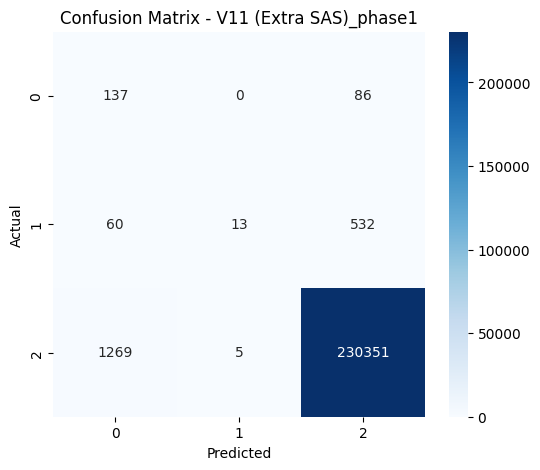

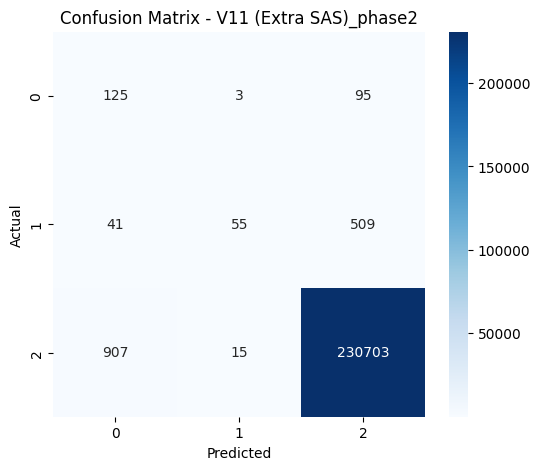

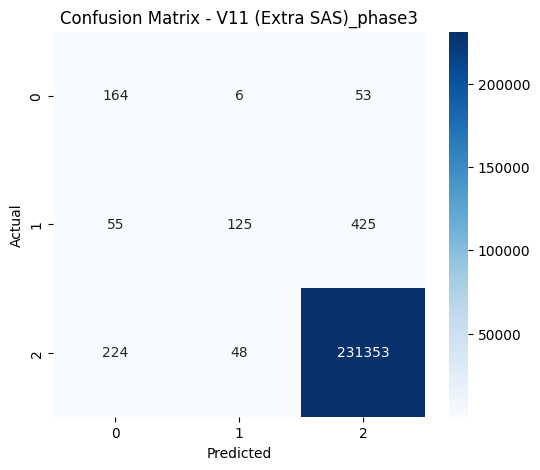

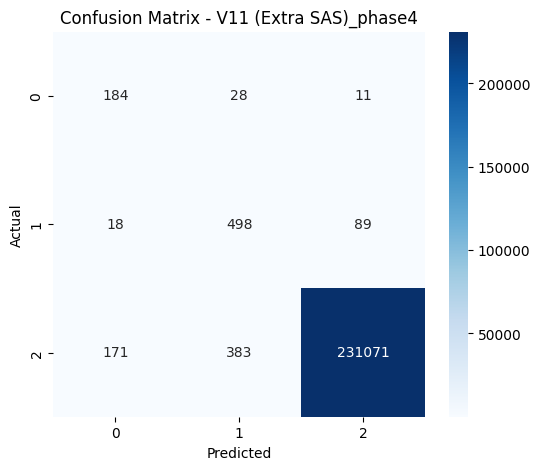

In [31]:
df_v11 = run_experiment(
    base_path=base_path,
    train_file="train_extra_sasmote.csv",
    val_file="val.csv",
    test_prefix="test",
    version_name="V11 (Extra SAS)"
)
df_v11

In [32]:
df_v11.to_csv("results_v11.csv", index=False)

## V12 (MissForest RadiusSMOTE)


#####
Version: V12 (Extra Radius)
#####
Loading train: /kaggle/input/lo-dataset/Extra_trees/Extra_trees/train_extra_radiussmote.csv
Combined train + val: 5791443 samples
Phase 1: 39 features
Phase 2: 39 features
Phase 3: 39 features
Phase 4: 39 features
Time-series shape: (5791443, 4, 39)
Static feature shape: (5791443, 23)
Classes: [0 1 2]
Epoch 1: loss = 0.0378
Epoch 2: loss = 0.0144
Epoch 3: loss = 0.0114
Epoch 4: loss = 0.0099
Epoch 5: loss = 0.0091
Epoch 6: loss = 0.0086
Epoch 7: loss = 0.0081
Epoch 8: loss = 0.0079
Epoch 9: loss = 0.0076
Epoch 10: loss = 0.0074
Epoch 11: loss = 0.0072
Epoch 12: loss = 0.0071
Epoch 13: loss = 0.0070
Epoch 14: loss = 0.0068
Epoch 15: loss = 0.0067
Epoch 16: loss = 0.0067
Epoch 17: loss = 0.0066
Epoch 18: loss = 0.0065
Epoch 19: loss = 0.0065
Epoch 20: loss = 0.0064
Epoch 21: loss = 0.0063
Epoch 22: loss = 0.0063
Epoch 23: loss = 0.0062
Epoch 24: loss = 0.0062
Epoch 25: loss = 0.0061
Epoch 26: loss = 0.0061
Epoch 27: loss = 0.0060
Epoch 28: loss = 

,Version,Phase,TimeBuildModel,TimePredict,Accuracy,BalancedAcc,Precision Macro,Precision Weighted,Recall Macro,Recall Weighted,F1-Score Macro,F1-Score Weighted,GMean,MCC,Kappa,Precision_Excellent,Recall_Excellent,F1-Score_Excellent,G-Mean_Excellent,Precision_Good,Recall_Good,F1-Score_Good,G-Mean_Good,Precision_Average,Recall_Average,F1-Score_Average,G-Mean_Average
0,V12 (Extra Radius),1,4243.88814,0.079909,0.994678,0.458793,0.458373,0.994206,0.458793,0.994678,0.426400,0.994252,0.373210,0.160857,0.159566,0.141473,0.327354,0.197564,0.571603,0.236641,0.051240,0.084239,0.226313,0.997006,0.997785,0.997396,0.401842
1,V12 (Extra Radius),2,4243.88814,0.080160,0.992192,0.581595,0.451248,0.994840,0.581595,0.992192,0.492195,0.993421,0.603244,0.253899,0.241274,0.212524,0.502242,0.298667,0.708057,0.143403,0.247934,0.181708,0.496967,0.997817,0.994608,0.996210,0.623854
2,V12 (Extra Radius),3,4243.88814,0.079959,0.993857,0.726462,0.549118,0.996485,0.726462,0.993857,0.609235,0.994976,0.791343,0.459183,0.431104,0.367953,0.556054,0.442857,0.745348,0.280443,0.628099,0.387755,0.790859,0.998960,0.995234,0.997093,0.840690
3,V12 (Extra Radius),4,4243.88814,0.079747,0.997307,0.826928,0.702154,0.997778,0.826928,0.997307,0.754977,0.997502,0.873781,0.675955,0.670160,0.534375,0.766816,0.629834,0.875399,0.572751,0.715702,0.636297,0.845403,0.999334,0.998264,0.998799,0.901442


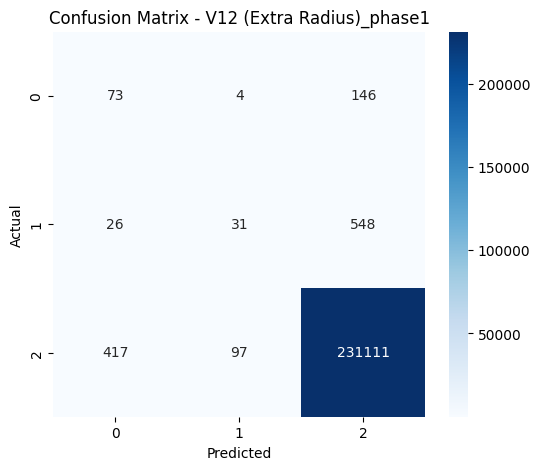

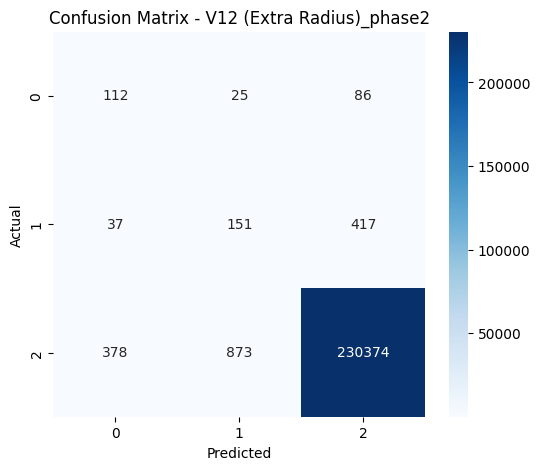

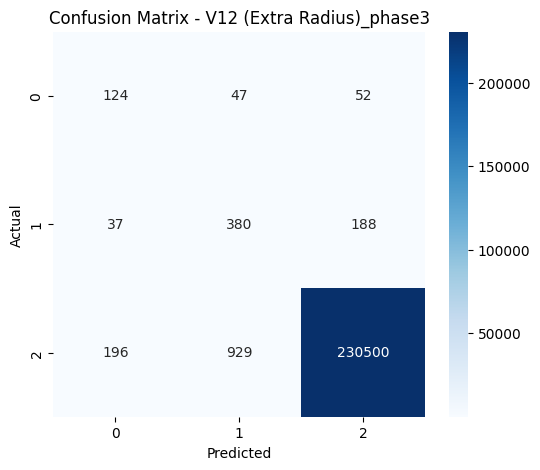

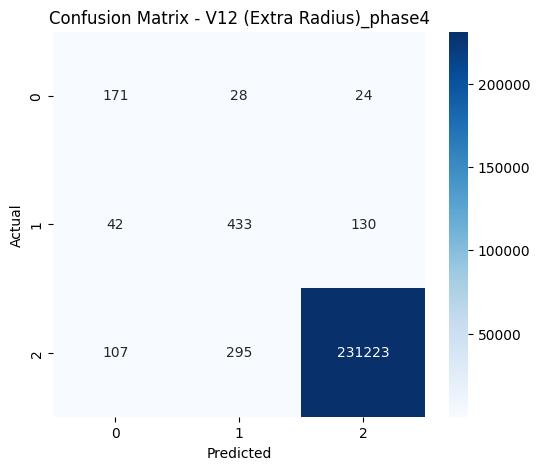

In [33]:
df_v12 = run_experiment(
    base_path=base_path,
    train_file="train_extra_radiussmote.csv",
    val_file="val.csv",
    test_prefix="test",
    version_name="V12 (Extra Radius)"
)
df_v12

In [34]:
df_v12.to_csv("results_v12.csv", index=False)